<a href="https://colab.research.google.com/github/jpaudel1-art/jpaudel1.github.io/blob/main/colab-notebooks/Week3_SelfAttention_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3: Self-Attention and Transformers

## Live Coding Activity (Google Colab)

This activity connects the Week 2 pipeline—text to tokens, token IDs, and embeddings—to the self-attention mechanism used by Transformers.

### Objectives

- Implement scaled dot-product attention from scratch.
- Use PyTorch tensors for matrix operations.
- Visualize attention weights.
- Compare embeddings before and after attention.
- Verify the calculation with PyTorch's MultiheadAttention.

> This notebook uses a toy example. Its vectors are not trained language-model representations; they make the attention calculation visible.


## Setup

In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.set_printoptions(precision=3, sci_mode=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Section 1: Review Embeddings from Week 2

A token ID is an index. An embedding layer maps each ID to a learned dense vector. Self-attention then lets each token update its vector by gathering information from other tokens in the same sequence.


In [2]:
tokens = ["plants", "need", "sunlight", "and", "water"]
word_to_id = {word: index for index, word in enumerate(tokens)}
token_ids = torch.tensor([word_to_id[word] for word in tokens])

embedding_layer = nn.Embedding(num_embeddings=len(tokens), embedding_dim=8)
week2_embeddings = embedding_layer(token_ids)

print("Tokens:", tokens)
print("Token IDs:", token_ids.tolist())
print("Embedding shape:", tuple(week2_embeddings.shape))

# fill the code 1: print out the embedding for "plants"
print("Embedding for plants:", )

Tokens: ['plants', 'need', 'sunlight', 'and', 'water']
Token IDs: [0, 1, 2, 3, 4]
Embedding shape: (5, 8)
Embedding for plants:


**Quick discussion:** Why can a neural network perform calculations with an embedding vector but not with a raw word? Why are IDs only labels rather than meaningful quantities?

## Section 2: Create Toy Embeddings

The input is a matrix with one row per token and eight features per embedding.


In [3]:
sequence_length = 5
embedding_dim = 8
embeddings = torch.rand(sequence_length, embedding_dim, device=device)

print("embeddings.shape:", tuple(embeddings.shape))
print("Rows correspond to:", tokens)
print(embeddings.cpu())

embeddings.shape: (5, 8)
Rows correspond to: ['plants', 'need', 'sunlight', 'and', 'water']
tensor([[0.658, 0.491, 0.891, 0.145, 0.531, 0.159, 0.654, 0.328],
        [0.653, 0.396, 0.915, 0.204, 0.202, 0.202, 0.950, 0.667],
        [0.981, 0.087, 0.004, 0.109, 0.164, 0.703, 0.679, 0.915],
        [0.242, 0.159, 0.765, 0.298, 0.803, 0.381, 0.786, 0.112],
        [0.248, 0.652, 0.606, 0.373, 0.798, 0.840, 0.137, 0.233]])


## Section 3: Create Query, Key, and Value (Q, K, V)

Q, K, and V are different learned projections of the input embeddings:

- Query: what a token is looking for.
- Key: what a token offers for matching.
- Value: information a token contributes when attended to.

They are learned representations, not fixed linguistic categories.


In [4]:
attention_dim = 8
query_layer = nn.Linear(embedding_dim, attention_dim, bias=False).to(device)
key_layer = nn.Linear(embedding_dim, attention_dim, bias=False).to(device)
value_layer = nn.Linear(embedding_dim, attention_dim, bias=False).to(device)

Q = query_layer(embeddings)
K = key_layer(embeddings)
V = value_layer(embeddings)

print("Q shape:", tuple(Q.shape))
print("K shape:", tuple(K.shape))
print("V shape:", tuple(V.shape))

Q shape: (5, 8)
K shape: (5, 8)
V shape: (5, 8)


## Section 4: Compute Attention Scores

The matrix product Q multiplied by K transpose compares every query with every key. A row represents the query token; a column represents the candidate key token.


In [6]:

# fill the code 1: print out the embedding for "plants"
print("Embedding for plants:", week2_embeddings[word_to_id["plants"]])
# fill the code 2: caculate the attention scores
attention_scores = torch.matmul(Q, K.transpose(-1, -2))

print("attention_scores.shape:", tuple(attention_scores.shape))
print("Raw QK transpose scores:")
print(attention_scores.cpu())

Embedding for plants: tensor([ 1.927,  1.487,  0.901, -2.106,  0.678, -1.235, -0.043, -1.605],
       grad_fn=<SelectBackward0>)
attention_scores.shape: (5, 5)
Raw QK transpose scores:
tensor([[-0.009,  0.204,  0.296, -0.098, -0.112],
        [-0.094,  0.075,  0.304, -0.140, -0.171],
        [ 0.035,  0.115,  0.659,  0.008,  0.007],
        [-0.177,  0.018, -0.067, -0.178, -0.230],
        [ 0.066,  0.384,  0.564, -0.010, -0.060]], grad_fn=<MmBackward0>)


**Predict:** After softmax, what should the sum of every row in the attention matrix be?

## Section 5: Scale and Normalize Scores

Scaled dot-product attention uses:

Attention(Q, K, V) = softmax(QK transpose / sqrt(d_k)) V

Scaling prevents large dot products from making softmax too peaked. Softmax converts each row to weights that sum to one.


In [7]:
scaled_scores = attention_scores / math.sqrt(attention_dim)
attention_weights = torch.softmax(scaled_scores, dim=-1)

print("attention_weights.shape:", tuple(attention_weights.shape))
print(attention_weights.cpu())
print("Row sums:", attention_weights.sum(dim=-1).cpu())

attention_weights.shape: (5, 5)
tensor([[0.195, 0.210, 0.217, 0.189, 0.188],
        [0.193, 0.205, 0.223, 0.190, 0.188],
        [0.190, 0.196, 0.237, 0.188, 0.188],
        [0.196, 0.210, 0.204, 0.196, 0.193],
        [0.191, 0.213, 0.227, 0.186, 0.182]], grad_fn=<SoftmaxBackward0>)
Row sums: tensor([1.000, 1.000, 1.000, 1.000, 1.000], grad_fn=<SumBackward1>)


## Section 6: Aggregate the Values

Each output embedding is a weighted combination of all value vectors. It is a context-aware representation of the original token.


In [10]:
# fill the code 3: caculate the attention output
attention_output =torch.matmul(attention_weights, V)
print("attention_output.shape:", tuple(attention_output.shape))

for index, token in enumerate(tokens):
    print("\nToken:", token)
    print("Original embedding:", embeddings[index].detach().cpu())
    print("After attention:  ", attention_output[index].detach().cpu())

attention_output.shape: (5, 8)

Token: plants
Original embedding: tensor([0.658, 0.491, 0.891, 0.145, 0.531, 0.159, 0.654, 0.328])
After attention:   tensor([-0.263, -0.139, -0.308, -0.448,  0.259, -0.068,  0.267, -0.382])

Token: need
Original embedding: tensor([0.653, 0.396, 0.915, 0.204, 0.202, 0.202, 0.950, 0.667])
After attention:   tensor([-0.266, -0.141, -0.307, -0.449,  0.257, -0.070,  0.265, -0.381])

Token: sunlight
Original embedding: tensor([0.981, 0.087, 0.004, 0.109, 0.164, 0.703, 0.679, 0.915])
After attention:   tensor([-0.272, -0.147, -0.305, -0.451,  0.253, -0.075,  0.259, -0.377])

Token: and
Original embedding: tensor([0.242, 0.159, 0.765, 0.298, 0.803, 0.381, 0.786, 0.112])
After attention:   tensor([-0.260, -0.133, -0.311, -0.445,  0.262, -0.066,  0.269, -0.386])

Token: water
Original embedding: tensor([0.248, 0.652, 0.606, 0.373, 0.798, 0.840, 0.137, 0.233])
After attention:   tensor([-0.266, -0.144, -0.305, -0.451,  0.257, -0.071,  0.265, -0.379])


**Discuss:** Is attention permanent memory? Explain why it is better described as weighted aggregation for the current calculation.

## Section 7: Visualize the Attention Matrix

Read a row from left to right. For example, the row for plants shows how much plants attends to every token, including itself.


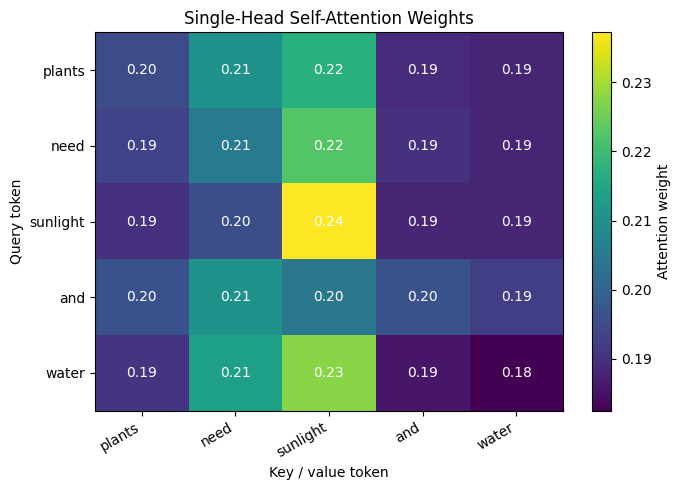

   plants attends most to: sunlight
     need attends most to: sunlight
 sunlight attends most to: sunlight
      and attends most to: need
    water attends most to: sunlight


In [11]:
plt.figure(figsize=(7, 5))
plt.imshow(attention_weights.detach().cpu(), cmap="viridis", aspect="auto")
plt.colorbar(label="Attention weight")
plt.xticks(range(sequence_length), tokens, rotation=30, ha="right")
plt.yticks(range(sequence_length), tokens)
plt.xlabel("Key / value token")
plt.ylabel("Query token")
plt.title("Single-Head Self-Attention Weights")

for i in range(sequence_length):
    for j in range(sequence_length):
        weight = attention_weights[i, j].item()
        color = "white" if weight < 0.35 else "black"
        plt.text(j, i, f"{weight:.2f}", ha="center", va="center", color=color)

plt.tight_layout()
plt.show()

for query_token, key_id in zip(tokens, attention_weights.argmax(dim=-1).cpu().tolist()):
    print(f"{query_token:>9} attends most to: {tokens[key_id]}")

## Section 8: Compare with PyTorch MultiheadAttention

We use one attention head and copy the manual Q, K, and V projection weights into PyTorch's module. The output projection is set to the identity matrix. The manual and module outputs should match except for tiny floating-point differences.


In [12]:
pytorch_attention = nn.MultiheadAttention(
    embed_dim=embedding_dim,
    num_heads=1,
    bias=False,
    batch_first=True,
    dropout=0.0
).to(device)

with torch.no_grad():
    pytorch_attention.in_proj_weight.copy_(
        torch.cat([query_layer.weight, key_layer.weight, value_layer.weight], dim=0)
    )
    pytorch_attention.out_proj.weight.copy_(torch.eye(embedding_dim, device=device))

attention_input = embeddings.unsqueeze(0)
module_output, module_weights = pytorch_attention(
    attention_input, attention_input, attention_input,
    need_weights=True, average_attn_weights=False
)
module_output = module_output.squeeze(0)
module_weights = module_weights.squeeze(0).squeeze(0)

print("Manual output shape:", tuple(attention_output.shape))
print("Module output shape:", tuple(module_output.shape))
print("Outputs match:", torch.allclose(attention_output, module_output, atol=1e-6))
print("Weights match:", torch.allclose(attention_weights, module_weights, atol=1e-6))
print("Maximum output difference:", (attention_output - module_output).abs().max().item())

Manual output shape: (5, 8)
Module output shape: (5, 8)
Outputs match: True
Weights match: True
Maximum output difference: 2.9802322387695312e-08


1. What are the shapes of Q, K, V, QK transpose, attention weights, and the final attention output?Assuming your sequence length is $5$ and your attention dimension ($d_k$ or attention_dim) is $8$:Q, K, and V: $(5, 8)$ — 5 tokens, each represented by an 8-dimensional vector.QK transpose ($\text{Q} \times \text{K}^T$): $(5, 5)$ — A square matrix showing how every token relates to every other token.Attention weights: $(5, 5)$ — The same square shape, but converted into probabilities (percentages) that sum up to 1 for each row.Final attention output: $(5, 8)$ — Back to the original token shape $(5, 8)$, but now containing the updated context from all the other tokens.2. What does one row of the attention-weight matrix represent?One row represents a single token looking at all other tokens (including itself) to figure out how much "attention" or importance it should give to each of them. For example, the row for the word "sunlight" will show a breakdown of how much it cares about "plants", "need", "sunlight", "and", and "water".3. Why do we divide by square root of $d_k$ before softmax?As the attention dimension ($d_k$) gets larger, the dot products ($Q \times K^T$) can grow very large in magnitude. When numbers are too large, the Softmax function pushes them into areas where the gradients become almost zero (flatlining). Dividing by $\sqrt{d_k}$ scales the numbers down to a stable range, keeping the Softmax gradients healthy so the model can learn effectively.4. How is an attention output embedding different from the original embedding?Original embedding: Just holds the meaning of a single word in isolation (e.g., what "sunlight" means by itself).Attention output embedding: Holds the meaning of the word in context (e.g., what "sunlight" means when it is sitting next to "plants" and "water"). It has absorbed context from the other relevant words in the sentence.5. Why does a Transformer need positional encoding?Unlike older models (like RNNs/LSTMs) that process text one word at a time in order, a Transformer processes all words simultaneously (in parallel). Because of this parallel processing, the model treats a sentence like a "bag of words" and has no built-in sense of word order. Positional encodings are added to the word embeddings to give the model a mathematical "GPS" or stamp of where each word is located in the sequence (e.g., knowing whether "cats eat fish" or "fish eat cats").

## Exit Ticket

Answer in a Markdown cell:

1. What are the shapes of Q, K, V, QK transpose, attention weights, and the final attention output?
2. What does one row of the attention-weight matrix represent?
3. Why do we divide by square root of d_k before softmax?
4. How is an attention output embedding different from the original embedding?
5. Why does a Transformer need positional encoding?

## Instructor Notes: Common Misconceptions

- **Attention is not memory.** It is a weighted aggregation mechanism.
- **Queries, keys, and values are learned representations**, not fixed linguistic concepts.
- **Multi-head attention does not simply repeat the same computation.** Each head learns separate projections and may capture different relationships.
- **Self-attention alone is permutation invariant.** Positional encoding supplies token-order information.

### Optional extension

Change the module to two heads while keeping the embedding dimension at eight. Inspect the returned attention-weight shape and explain why each head has its own attention pattern.

## Key takeaway

Self-attention transforms each token embedding into a context-aware vector by comparing queries and keys, normalizing scores into weights, and aggregating values.
